## imports

In [105]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:

from ult import *
import multiprocess
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


# use new data

In [107]:
modelnamefull='seed_0_varyrewardpv2_epoch_11'
# modelname = 'varyrewardperoid2'
# thismodel = f'seed_{seed}_{modelname}_{modeli}'

# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0
plot_no_episodes = 333

no_episodes = 2222
epochtouse = 8

attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
seed = 0
np.random.seed(seed)

vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
env_param = [0, None, attcost, .25, facost, 0, 0]


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
# model = PPO.load(f'ycstore/{ thismodel}_epoch_{epochtouse}')
# print(f'ycstore/{thismodel}_epoch_{epochtouse}')
model=PPO.load(f'ycstore/{modelnamefull}')


In [108]:
# # collect trial data
# def eval_wrapper(a):
#     episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
#                               num_steps=100000, deterministic=True)
#     return episode


# with multiprocess.Pool(processes=8) as pool:
#     all_episode_data = pool.map(eval_wrapper, range(no_episodes))

# use figdata

In [137]:
# save_pickle_file('figdata/peroid.pkl', all_episode_data)
all_episode_data = open_pickle_file('figdata/peroid.pkl')

In [138]:
# process the data.
all_reward_res={} # k: v = foodreward idx: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len


for episode in all_episode_data[:]:
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
 
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    else:
        lick_time_list.append(-1)
    trial_len.append(len(episode['actions']))

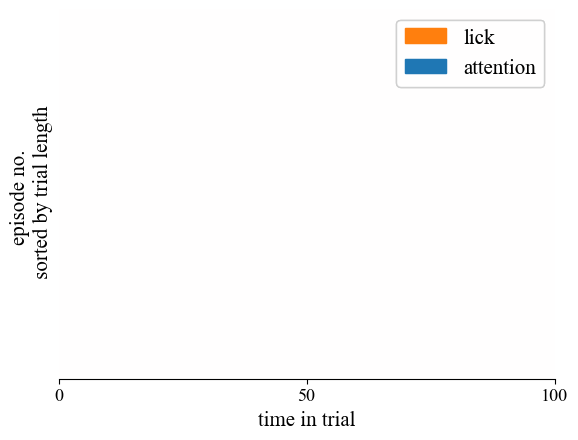

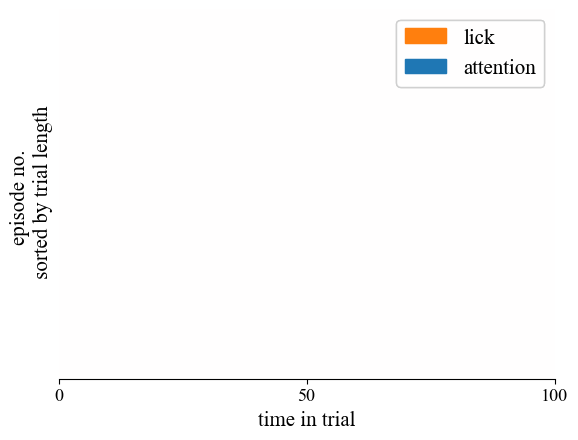

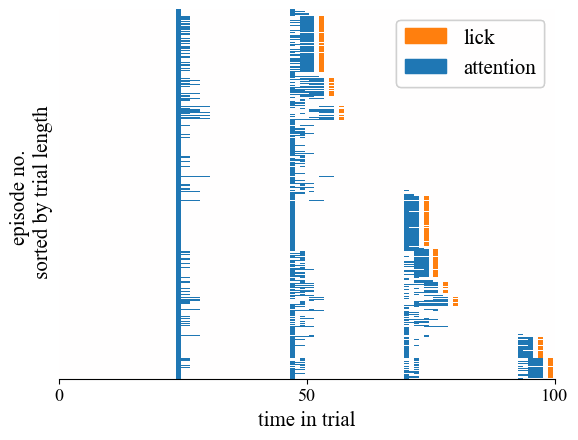

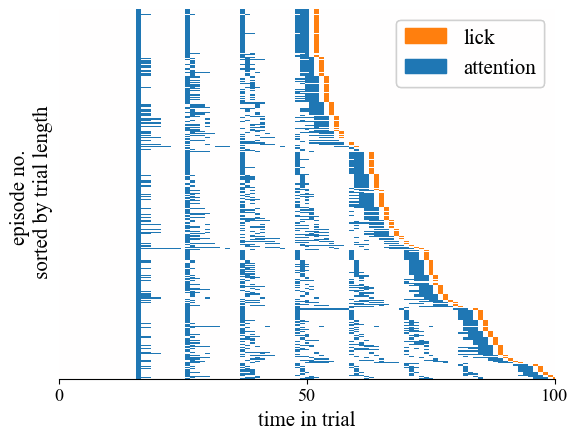

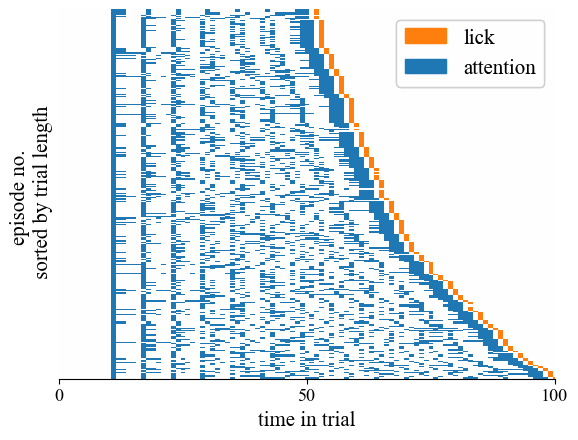

In [139]:
# heatmap trial indicator (att and lick) new, select len
minlen, maxlen = 50, 100

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    trial_len = np.array(trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))

    sortind = np.argsort([trial_len[i] for i in valid_ind])
    valid_ind = valid_ind[sortind]

    # att
    plot_data = [att_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data = [lick_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    if np.sum(grid) == 0:
        continue
    fig=plt.figure()

    colors = [attn_color, 'white', lick_color]
    stops = [0.0, 0.5, 1.0]
    attnlickcmap = LinearSegmentedColormap.from_list(
        'custom_cmap', list(zip(stops, colors)))

    c = plt.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                   aspect='auto', interpolation='none')

    plt.xticks([0, 50, 100])
    plt.xlim(0, 100)
    plt.yticks([])
    ax = plt.gca()
    ax.spines['left'].set_visible(False)
    plt.xlabel('time in trial')
    plt.ylabel('episode no. \n sorted by trial length')
    # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    lickdot = Patch(color=lick_color, label='lick')
    attdot = Patch(color=attn_color, label='attention')
    extra_legend = plt.legend(
        handles=[lickdot, attdot], bbox_to_anchor=(1, 1), frameon=True)
    ax.add_artist(extra_legend)
    # quickleg(ax)

    ax.add_artist(extra_legend)
    with plt.rc_context({'image.composite_image': False}):
        fig.savefig(f'fig/plot p/attn lick raster {food_reward_idx}.svg')
    plt.show()

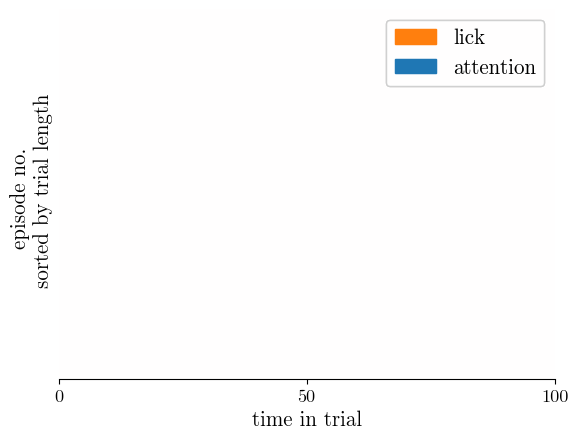

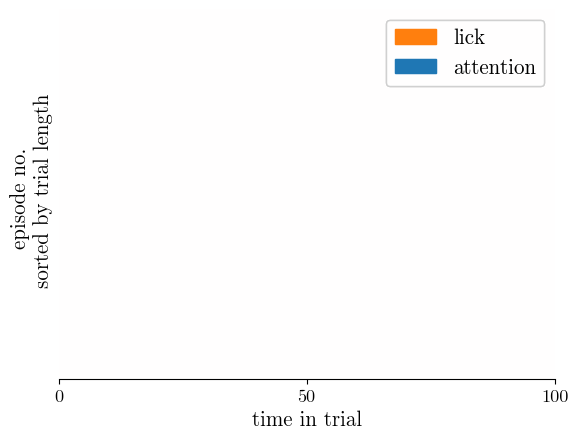

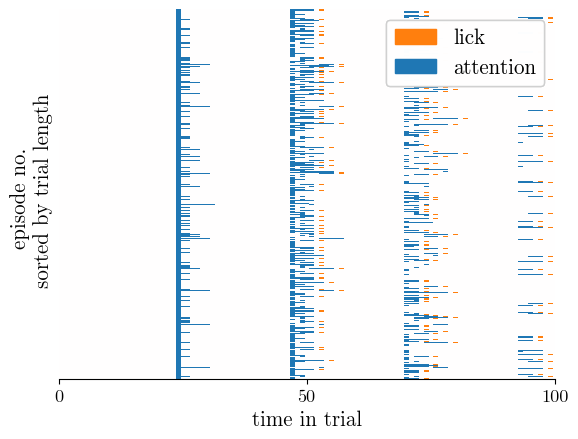

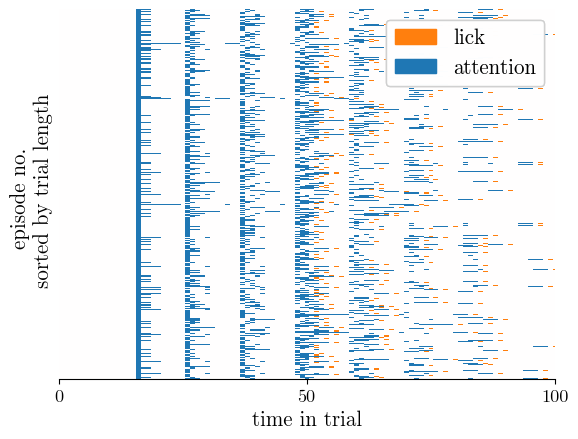

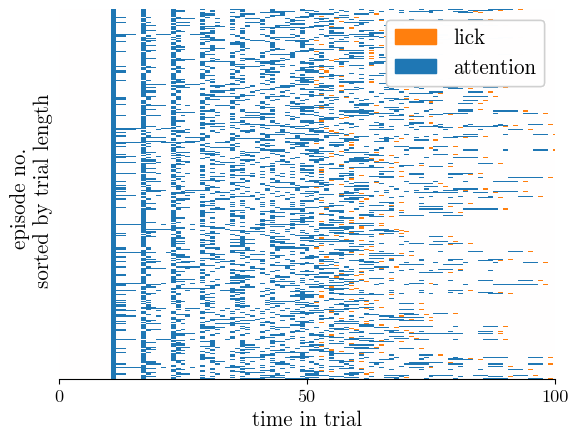

In [112]:
# heatmap trial indicator (att and lick) new, select len
minlen, maxlen = 50, 100

for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    trial_len = np.array(trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))

    # att
    plot_data = [att_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data = [lick_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    if np.sum(grid) == 0:
        continue
    fig=plt.figure()

    colors = [attn_color, 'white', lick_color]
    stops = [0.0, 0.5, 1.0]
    attnlickcmap = LinearSegmentedColormap.from_list(
        'custom_cmap', list(zip(stops, colors)))

    c = plt.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                   aspect='auto', interpolation='none')

    plt.xticks([0, 50, 100])
    plt.xlim(0, 100)
    plt.yticks([])
    ax = plt.gca()
    ax.spines['left'].set_visible(False)
    plt.xlabel('time in trial')
    plt.ylabel('episode no. \n sorted by trial length')
    # plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

    lickdot = Patch(color=lick_color, label='lick')
    attdot = Patch(color=attn_color, label='attention')
    extra_legend = plt.legend(
        handles=[lickdot, attdot], bbox_to_anchor=(1, 1), frameon=True)
    ax.add_artist(extra_legend)
    # quickleg(ax)

    ax.add_artist(extra_legend)


    with plt.rc_context({'image.composite_image': False}):
        fig.savefig(f'fig/plot p/attn lick raster {food_reward_idx} unsorted.svg')
    plt.show()


webf NOT subset; don't know how to subset; dropped


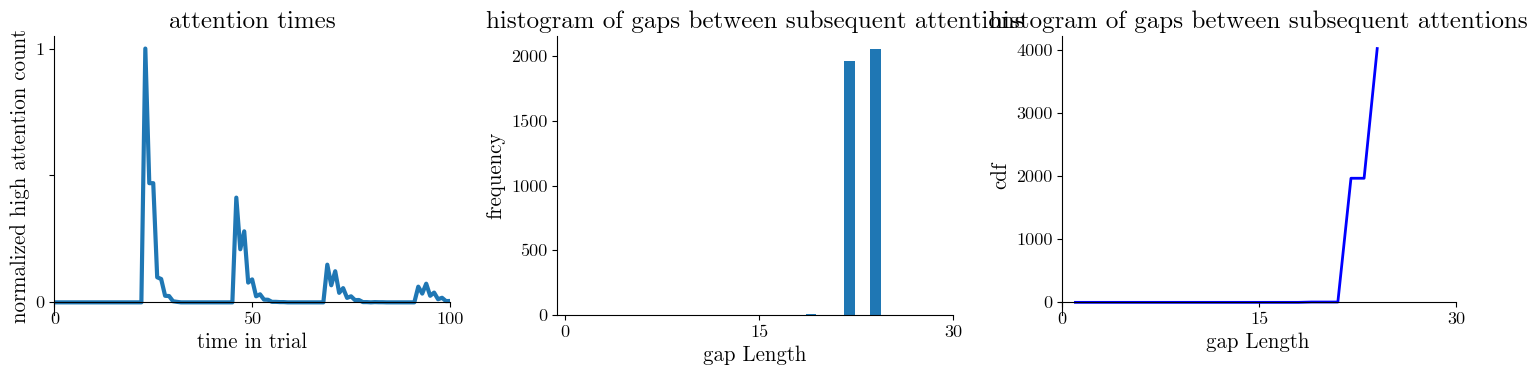

webf NOT subset; don't know how to subset; dropped


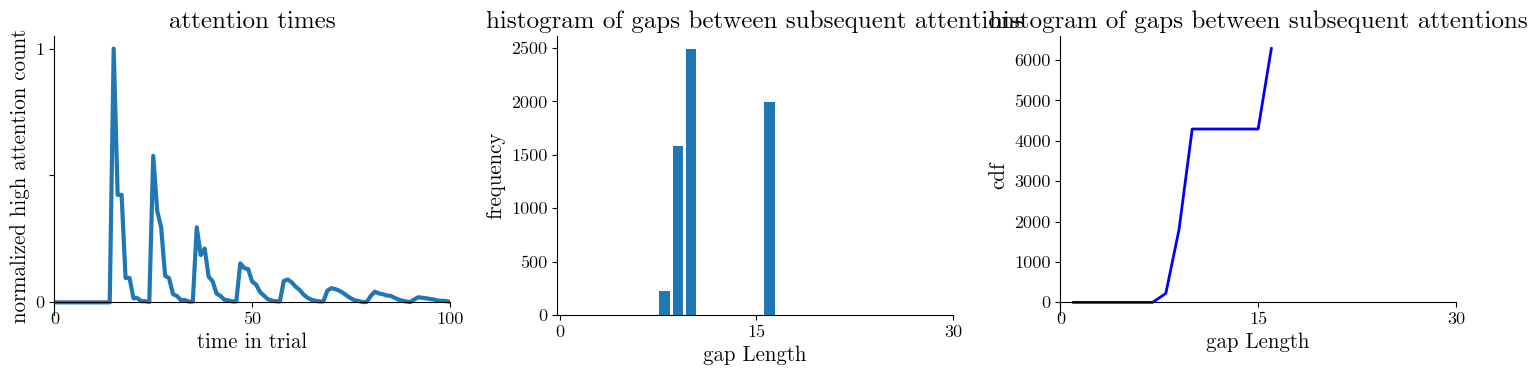

webf NOT subset; don't know how to subset; dropped


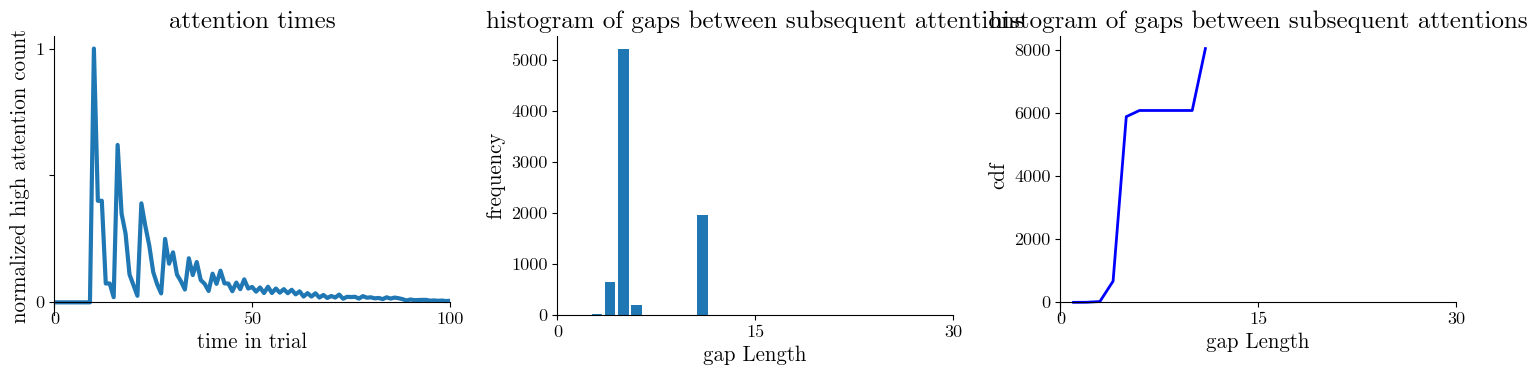

In [113]:
# att time
for food_reward_idx in (all_reward_res.keys()):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    title = f'reward: {food_reward_list[food_reward_idx]:.0f}'
    if len(att_time_list[0]) > 0:

        data = att_time_list
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
        plotdata = np.sum(pad_zero_attention(data), axis=0)/len(data)
        plotdata = plotdata[1:]  # remove the first iti state
        ax1.plot(plotdata, linewidth=3)
        ax1.set_xlabel('time in trial')
        ax1.set_ylabel('normalized high attention count')
        ax1.set_title('attention times')
        centerax(ax1)
        ax1.set_xticks([0, 50, 100])
        ax1.set_yticks([0, 0.5, 1], ['0', '', '1'])
        ax1.set_xlim(0, 100)

        histogram = gap_histogram_all_rows(pad_zero_attention(data))
        # sns.kdeplot(histogram[0], color='red',bw_adjust=.1)

        ax2.bar(histogram[1][:-1], histogram[0], width=0.8, align='center')
        ax2.set_xticks([0, 15, 30])
        ax2.set_xlabel('gap Length')
        ax2.set_ylabel('frequency')
        ax2.set_title(f'histogram of gaps between subsequent attentions')

        counts, bins = gap_histogram_all_rows(pad_zero_attention(data))
        bin_width = bins[1] - bins[0]

        counts, bins = gap_histogram_all_rows(pad_zero_attention(data))
        bin_width = bins[1] - bins[0]
        pdf = counts / (np.sum(counts) * bin_width)
        cdf = np.cumsum(counts) * bin_width
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(cdf)
        smoothed_cdf = kde.integrate_box_1d(-np.inf, bins[:-1])
        # ax3.plot(bins[:-1], pdf, color='red', linestyle='-', linewidth=2, label='PDF')
        ax3.plot(bins[:-1], cdf, color='blue',
                 linestyle='-', linewidth=2, label='cdf')
        ax3.set_xlabel('gap Length')
        ax3.set_ylabel('cdf')
        centerax(ax3)
        ax3.set_xticks([0, 15, 30])
        ax3.set_title(f'histogram of gaps between subsequent attentions')

        # plt.suptitle(title)
        plt.tight_layout()
        quicksave(f'att time, gap, cdf {food_reward_idx}', 'plot p')
        plt.show()

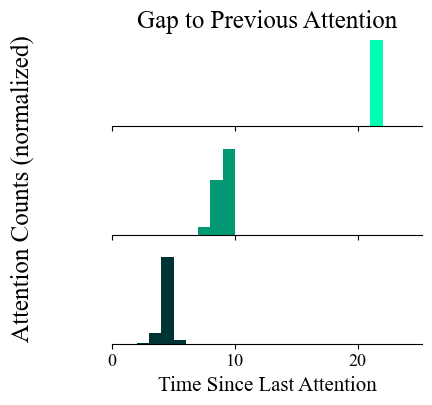

In [140]:
# side by side bar, seperated
use_reward = [2,3,4]
reward_labels = []
reward_data = []

for food_reward_idx, v in all_reward_res.items():
    if food_reward_idx in use_reward:
        attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = v
        att_gap2previous = [previous_item_gap(a) for a in att_time_list]
        a = np.concatenate(att_gap2previous)
        # Count occurrences of values within bins
        counts, bins = np.histogram(a, bins=np.linspace(2, 25, 25))
        # Normalize counts
        counts_normalized = counts / np.sum(counts)
        reward_labels.append(
            f'food reward={food_reward_list[food_reward_idx]:.0f}')
        reward_data.append(counts_normalized)

# Create side-by-side bar chart
fig, axs = plt.subplots(3, 1, figsize=(4, 4), sharex=True)
width = 1  # Width of each bar
x = np.arange(len(bins) - 1)

for i in range(len(reward_labels)):
    axs[i].bar(x + width/2, reward_data[i],
               width=width, label=reward_labels[i], color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])
    axs[i].spines['left'].set_visible(False)
    axs[i].set_yticks([])

axs[i].set_xlim(0, None)
axs[i].set_xticks([0, 10, 20])
axs[0].set_title('Gap to Previous Attention')
# axs[i].set_ylabel('Attention Counts (normalized)')
plt.suptitle('Attention Counts (normalized)', rotation='vertical', x=-0.1, y=0.5, va='center'
             )
axs[i].set_xlabel('Time Since Last Attention')

quicksave('gap verticle','plot p')
# plt.show()

In [115]:
# # side by side bar

# reward_labels = []
# reward_data = []

# for food_reward_idx, v in all_reward_res.items():
#     # if food_reward_idx in [0, 1, 2]:
#         attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = v
#         att_gap2previous = [previous_item_gap(a) for a in att_time_list]
#         a = np.concatenate(att_gap2previous)
        
#         # Count occurrences of values within bins
#         counts, bins = np.histogram(a, bins=np.linspace(2, 25, 25))
        
#         # Normalize counts
#         counts_normalized = counts / np.sum(counts)
        
#         reward_labels.append(f'food reward={food_reward_list[food_reward_idx]:.0f}')
#         reward_data.append(counts_normalized)

# # Create side-by-side bar chart
# fig, ax = plt.subplots()
# width = 0.2  # Width of each bar
# x = np.arange(len(bins) - 1)

# for i in range(len(reward_labels)):
#     ax.bar(x + i * width, reward_data[i], width=width, label=reward_labels[i])

# # Add labels and legend
# ax.set_title('Gap to Previous Attention')
# ax.set_ylabel('Attention Counts (normalized)')
# ax.set_xlabel('Time Since Last Attention')

# # Reduce number of xticks
# num_xticks = 6
# plt.xticks(np.arange(0, len(bins), step=int(len(bins) / num_xticks)), [f'{int(bin)}-{int(bin+1)}' for bin in bins[::int(len(bins) / num_xticks)]])
    
# ax.legend()

# plt.show()



# fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
# # auto correlation    
# for food_reward_idx in [2,3,4]:
#     att_seq_list = []
#     for episode in all_episode_data:
#         if episode['trial_food_reward_idx']==food_reward_idx:
#             att_seq_list.append([float(elt[1]) for elt in episode['actions']])
#     # Sorting based on increasing trial length
#     sorted_list_of_lists = sorted(att_seq_list, key=len)
#     sequences = sorted_list_of_lists[-333:-1] # Choosing what range of trial lengths to use. Could modify to be more consistent.
#     normalized_sequences = []
#     max_length = 0
#     for sequence in sequences:
#         normalized_seq = np.array(sequence)
#         if not np.isnan(normalized_seq.any()):
#             normalized_sequences.append(normalized_seq)
#             max_length = max(max_length, len(normalized_seq))    
        
#     padded_sequences = []
#     for seq in normalized_sequences:
#         padded_seq = np.pad(seq, (0, max_length - len(seq)), mode='constant')
#         padded_sequences.append(padded_seq)

#     autocorrelation_sum = np.zeros(2 * max_length - 1)
#     for seq in padded_sequences:
#         autocorrelation_sum += np.nan_to_num(compute_autocorrelation(seq), nan=0)


#     average_autocorrelation = autocorrelation_sum / len(padded_sequences)
#     xs=np.arange(0,len(average_autocorrelation),1)
#     xs=xs-len(xs)//2
#     ax1.plot(xs,average_autocorrelation,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
#     ax1.set_xlabel('tau')
#     ax1.set_ylabel('autocorrelation')
#     ax1.set_xlim(-80,80)
#     # ax1.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')
#     ax1.set_title('auto correlation')
#     ax1.legend()

#     # ax2.hist([len(a) for a in att_seq_list])
#     sns.kdeplot([len(a) for a in att_seq_list], fill=False, bw_adjust=0.5)
#     ax2.set_xlabel('trial length')
#     ax2.set_ylabel('probablity')
#     ax2.set_xlim(0,80)
#     ax2.set_title('trial length distribution')
#     # ax2.set_title(f'food reward={food_reward_list[food_reward_idx]:.0f} epoch:{i}')

# ax1.legend(bbox_to_anchor=(1,0))
# plt.tight_layout()
# # quicksave('autocorr', modelname)
# plt.show()

In [116]:
# # autocorr
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# use_reward = [2, 3, 4]
# # auto correlation
# for i, food_reward_idx in enumerate(use_reward):
#     att_seq_list = []
#     for episode in all_episode_data:
#         if episode['trial_food_reward_idx'] == food_reward_idx:
#             att_seq_list.append([float(elt[1])
#                                 for elt in episode['actions']])
#     # Sorting based on increasing trial length
#     sorted_list_of_lists = sorted(att_seq_list, key=len)
#     # Choosing what range of trial lengths to use. Could modify to be more consistent.
#     sequences = sorted_list_of_lists[-plot_no_episodes:]
#     # autocorr
#     autocorr, total_counts = empirical_autocorrelation(
#         sequences, min_no_samples=0)
#     xs = np.arange(0, len(autocorr), 1)
#     xs = xs-len(xs)//2
#     ax1.plot(xs, autocorr,
#              label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])
#     # trial len dist
#     sns.kdeplot([len(a) for a in att_seq_list],
#                 fill=False, bw_adjust=0.5, ax=ax2, color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])

#     ax1.set_xlabel(r'$\tau$ [s]')
#     ax1.set_title('auto correlation (log)')
#     ax1.set_xlim(-50, 50)
#     # ax1.set_ylim(0, .03)
#     ax1.set_xticks([-50, 0, 50])
#     ax1.set_yscale('log')
#     ax1.set_yticks([])
#     ax1.spines['left'].set_position('zero')

#     ax2.set_xlabel('trial length')
#     ax2.set_ylabel('probablity')
#     ax2.set_xlim(0, 80)
#     ax2.set_xticks([0, 40, 80])
#     ax2.set_yticks([])
#     ax2.set_title('trial length distribution')

# color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=rewardcmap), ax=ax2)
# ticks = [0, 0.5, 1]
# tick_labels = ['Low food reward', '', 'High food reward']
# color_bar.set_ticks(ticks)
# color_bar.set_ticklabels(tick_labels)


# fig.suptitle('varying reward, peroid')
# plt.tight_layout()
# # quicksave('autocorr', modelname)
# plt.show()

In [117]:
# # autocorr
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# use_reward = [2, 3, 4]
# # auto correlation
# for i, food_reward_idx in enumerate(use_reward):
#     att_seq_list = []
#     for episode in all_episode_data:
#         if episode['trial_food_reward_idx'] == food_reward_idx:
#             att_seq_list.append([float(elt[1])
#                                 for elt in episode['actions']])
#     # Sorting based on increasing trial length
#     sorted_list_of_lists = sorted(att_seq_list, key=len)
#     # Choosing what range of trial lengths to use. Could modify to be more consistent.
#     sequences = sorted_list_of_lists[-plot_no_episodes:]
#     # autocorr
#     autocorr, total_counts = empirical_autocorrelation(
#         sequences, min_no_samples=0)
#     xs = np.arange(0, len(autocorr), 1)
#     xs = xs-len(xs)//2
#     ax1.plot(xs, autocorr,
#              label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])
#     # trial len dist
#     sns.kdeplot([len(a) for a in att_seq_list],
#                 fill=False, bw_adjust=0.5, ax=ax2, color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])

#     ax1.set_xlabel(r'$\tau$ [s]')
#     ax1.set_title('auto correlation (log)')
#     ax1.set_xlim(-50, 50)
#     # ax1.set_ylim(0, .03)
#     ax1.set_xticks([-50, 0, 50])
#     # ax1.set_yscale('log')
#     ax1.set_yticks([])
#     ax1.spines['left'].set_position('zero')

#     ax2.set_xlabel('trial length')
#     ax2.set_ylabel('probablity')
#     ax2.set_xlim(0, 80)
#     ax2.set_xticks([0, 40, 80])
#     ax2.set_yticks([])
#     ax2.set_title('trial length distribution')

# color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=rewardcmap), ax=ax2)
# ticks = [0, 0.5, 1]
# tick_labels = ['Low food reward', '', 'High food reward']
# color_bar.set_ticks(ticks)
# color_bar.set_ticklabels(tick_labels)


# fig.suptitle('varying reward, peroid')
# plt.tight_layout()

# plt.show()

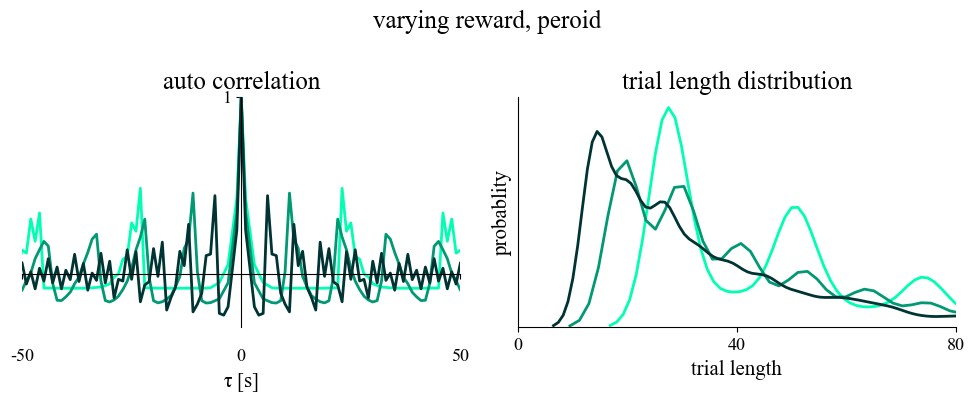

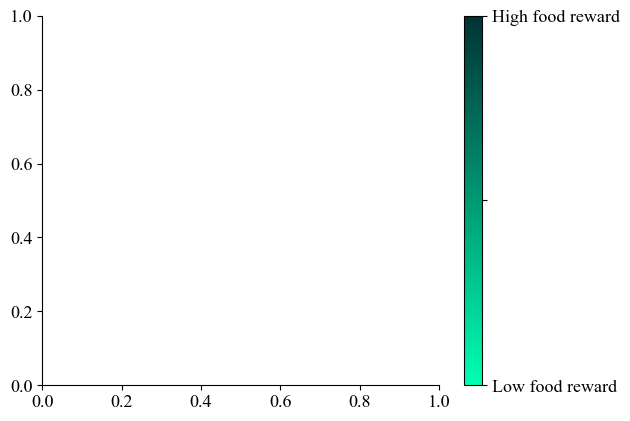

In [145]:
# autocorr
from ult import empirical_autocorrelation_new
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

use_reward = [2,3,4]
# auto correlation
for i, food_reward_idx in enumerate(use_reward):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation_new(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
             label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2, color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    ax1.set_ylim(-0.3, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_xticks([0, 40, 80])
    ax2.set_yticks([])
    ax2.set_title('trial length distribution')
fig.suptitle('varying reward, peroid')
plt.tight_layout()
quicksave('autocorr', 'plot p')

fig=plt.figure()
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=rewardcmap), ax=plt.gca())
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)
quicksave('varyreward cmap', 'plot p')



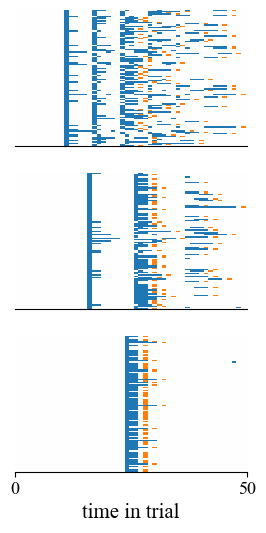

In [151]:
# heatmap trial indicator (att and lick) new, select len
minlen, maxlen = 25, 50
use_reward = [2, 3, 4]
fig, axs = plt.subplots(len(use_reward), 1, figsize=(
    3, len(use_reward)*2,))

for axi, food_reward_idx in enumerate(use_reward):
    attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
        food_reward_idx]
    trial_len = np.array(trial_len)
    valid_ind = np.where((minlen < trial_len) & (trial_len < maxlen))[0]
    grid = np.zeros((len(valid_ind), max(trial_len)+2))
    sortind = np.argsort([trial_len[i] for i in valid_ind])
    # valid_ind = valid_ind[sortind]

    # att
    plot_data = [att_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        grid[i, arr] = -1

    # lick
    plot_data = [lick_time_list[i] for i in valid_ind]
    for i, arr in enumerate(plot_data):
        if arr:
            grid[i, arr] = 1
    if np.sum(grid) == 0:
        print(food_reward_idx)
        continue

    colors = [attn_color, 'white', lick_color]
    stops = [0.0, 0.5, 1.0]
    attnlickcmap = LinearSegmentedColormap.from_list(
        'custom_cmap', list(zip(stops, colors)))
    ax=axs[len(use_reward)-axi-1]
    c = ax.imshow(grid, cmap=attnlickcmap, vmin=-1, vmax=1,
                        aspect='auto', interpolation='none')
    ax.set_xlim(0,50)
    ax.set_ylim(0,100)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
axs[-1].set_xticks([0,50])
axs[-1].set_xlabel('time in trial')
# plt.ylabel('episode no. \n sorted by trial length')
# plt.title(f'attn, food reward: {food_reward_list[food_reward_idx]}')

# lickdot = Patch(color=lick_color, label='lick')
# attdot = Patch(color=attn_color, label='attention')
# extra_legend = plt.legend(
#     handles=[lickdot, attdot], bbox_to_anchor=(0, 1), frameon=True)
# ax.add_artist(extra_legend)


# quicksave(f'ep indicator {food_reward_idx}', modelname)

with plt.rc_context({'image.composite_image': False}):
    fig.savefig(f'fig/plot p/autocorr raster.svg')
plt.show()


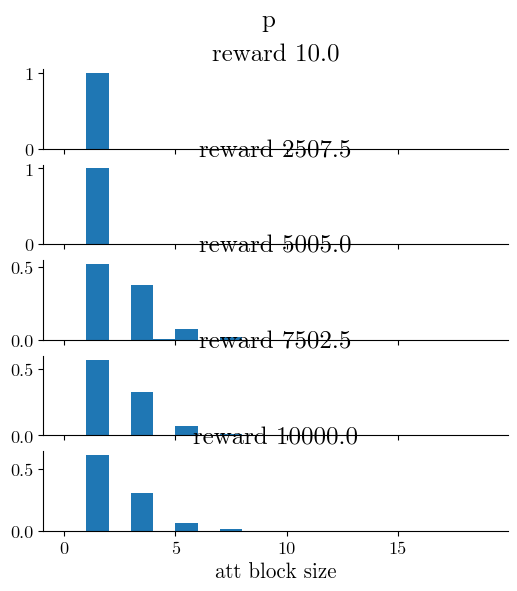

In [120]:
from ult import find_block_lengths
fig,axs=plt.subplots(5,1, sharex=True, figsize=(6,6))
for food_reward_idx in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    ax=axs[food_reward_idx]
    ax.hist(np.concatenate([find_block_lengths(a) for a in att_time_list]), density=True, bins=np.arange(20))
    ax.set_title(f'reward {food_reward_list[food_reward_idx]}')
# plt.xlim(0,10)
plt.xlabel('att block size')
plt.suptitle('p')
plt.show()

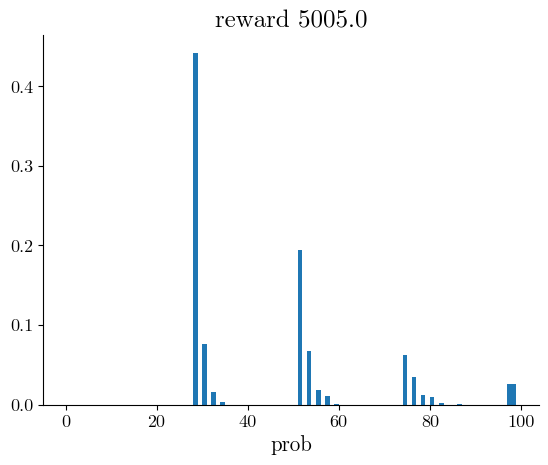

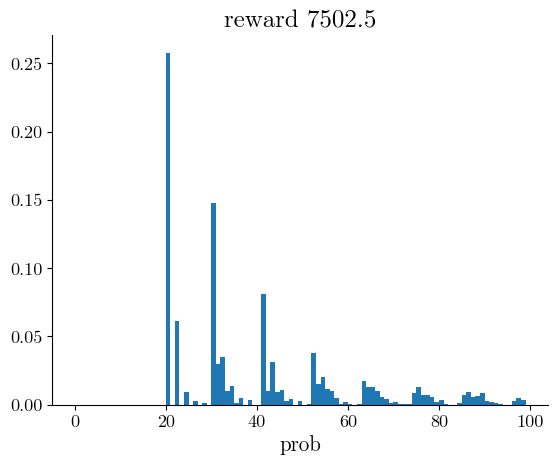

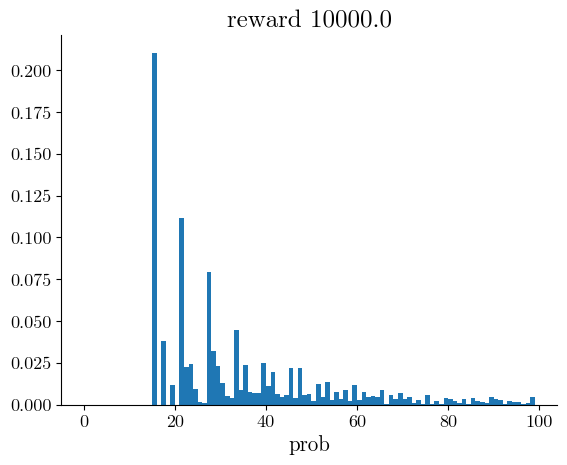

In [121]:

for food_reward_idx in [2,3,4]:
    attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[food_reward_idx]
    fig,ax=plt.subplots(1,1)
    ax.hist(lick_time_list, bins=np.arange(100), density=True)
    ax.set_title(f'reward {food_reward_list[food_reward_idx]}')
    plt.xlabel('time in trial')
    plt.xlabel('prob')

# test

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/1332225256.py:25: RuntimeWarning: Mean of empty slice
  mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/1332225256.py:59: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


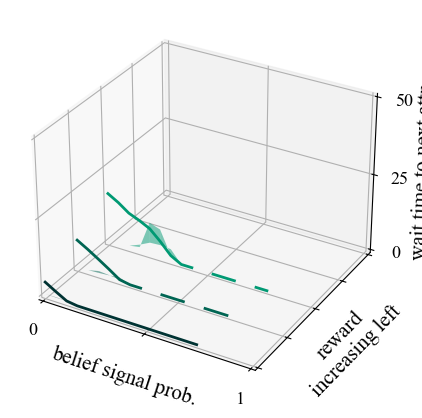

In [125]:
# imshow 3d
%matplotlib inline
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

vmin,vmax=0,50
nbin=20
bins=np.linspace(0,1,nbin)
plotdata=[] # for plot data

for food_reward_idx in range(len(food_reward_list)):
    bindata=[[] for _ in range(nbin)] 
    subdf=df[(df.trial_food_reward_idx==food_reward_idx)]
    sb, nextatt=[],[]
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a,b=trialnextatt(alist,b),trialsb(b)  
            for j in range(len(b)):
                thisa,thisb=a[j], b[j]
                for i, (s,e) in enumerate(zip(bins, bins[1:])):
                    if s<thisb<=e:
                        bindata[i].append(thisa)
        except:
            continue

    mu, err=[np.nanmean(a) for a in bindata],[np.nanstd(a) for a in bindata]
    mu, err=np.array(mu), np.array(err)
    # plt.errorbar(bins,mu, err)
    # plt.fill_between(bins,mu-err, mu+err, alpha=0.6, color=rewardcmap(
    #     np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    percentile_5 = np.array([np.percentile(data, 5) if data else 0 for data in bindata])
    percentile_95 = np.array([np.percentile(data, 95) if data else 0 for data in bindata])
    lowerr=np.clip(mu-percentile_5, 0,None)
    higherr=np.clip(percentile_95-mu, 0,None)
    # plt.errorbar(bins-0.01*food_reward_idx,mu, [lowerr, higherr], color=rewardcmap(
    #     np.linspace(0, 1, len(food_reward_list)))[food_reward_idx])
    plotdata.append([lowerr, higherr, mu])

y_values = np.arange(len(food_reward_list)-1, -1,-1)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
for y, (y1, y2, mu) in zip(y_values, plotdata):
    verts = []
    for i in range(len(bins) - 1):
        verts.append([(bins[i], y, y1[i]), (bins[i+1], y, y1[i+1]), (bins[i+1], y, y2[i+1]), (bins[i], y, y2[i])])
    poly = Poly3DCollection(verts, facecolors=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1], alpha=0.5, edgecolors='none')
    ax.add_collection3d(poly)
    ax.plot(bins,np.zeros_like(bins)+y, mu,color=rewardcmap(np.linspace(0, 1, len(food_reward_list)))[len(food_reward_list)-y-1])

ax.set_xlim(0, 1)
ax.set_ylim(0, 2)
ax.set_zlim(0, 50)
ax.set_xlabel('belief signal prob.',labelpad=1)
ax.set_yticks([0,1,2,3,4],[])
ax.set_zticks([0,25,50])
ax.set_xticks([0,0.5,1],['0','','1'])
ax.set_ylabel('reward\nincreasing left',labelpad=1)
ax.set_zlabel('wait time to next attn.',labelpad=1)

plt.tight_layout()
quicksave('vary reward 3d p','plot wait time', fig=fig)
plt.show()


/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:56: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


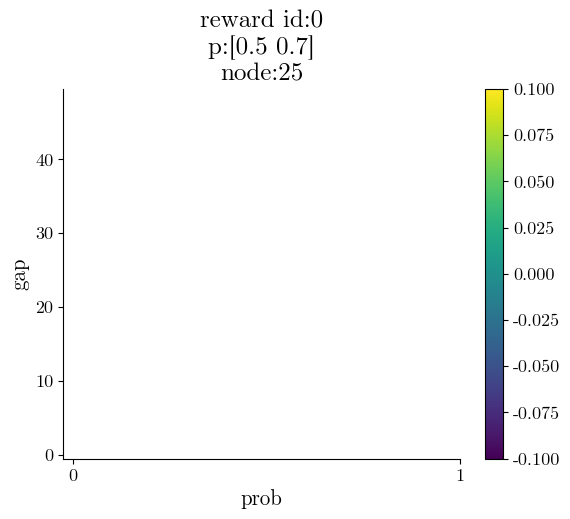

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:56: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


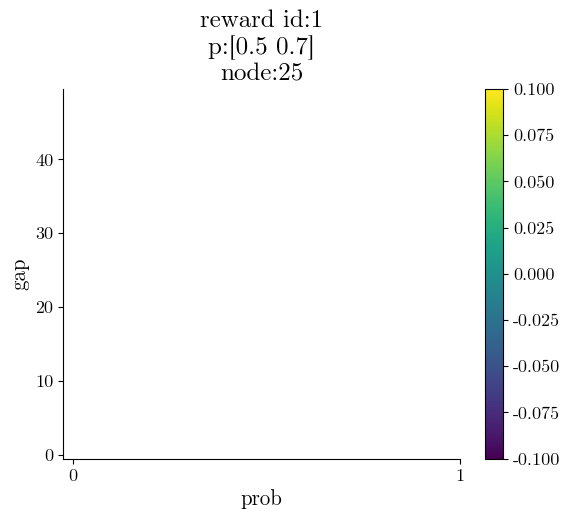

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:56: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


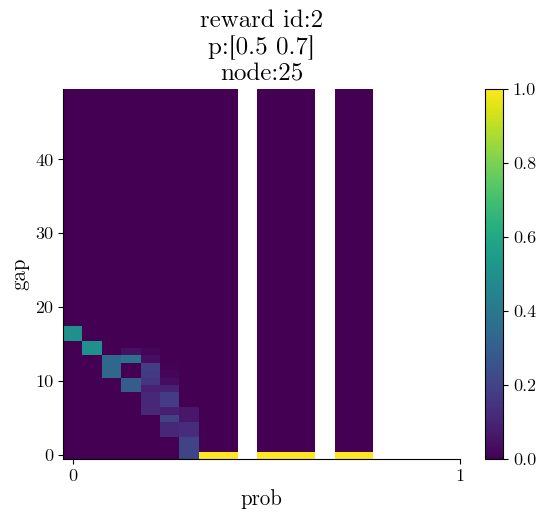

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:56: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


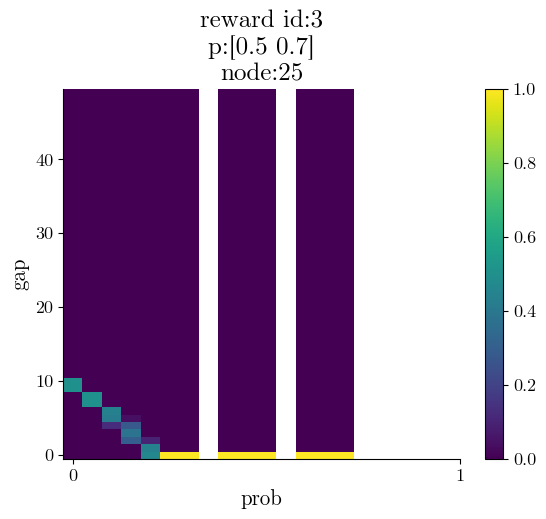

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:56: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


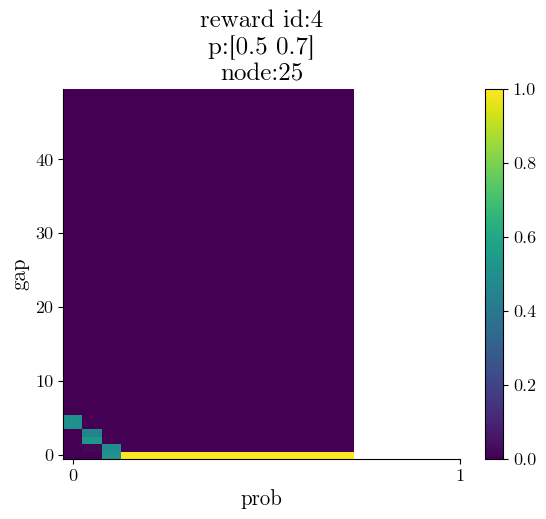

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:88: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


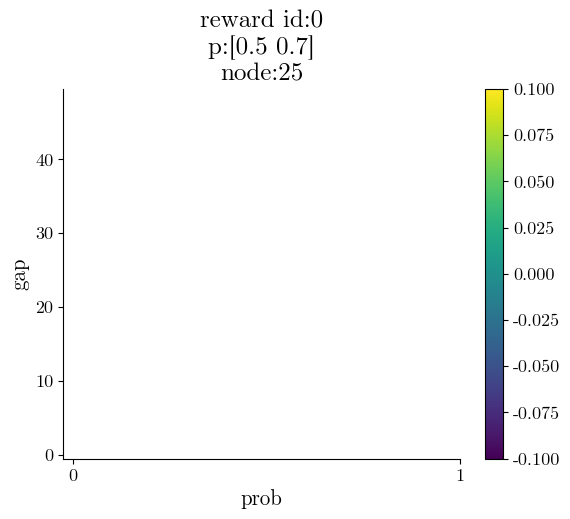

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:88: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
webf NOT subset; don't know how to subset; dropped


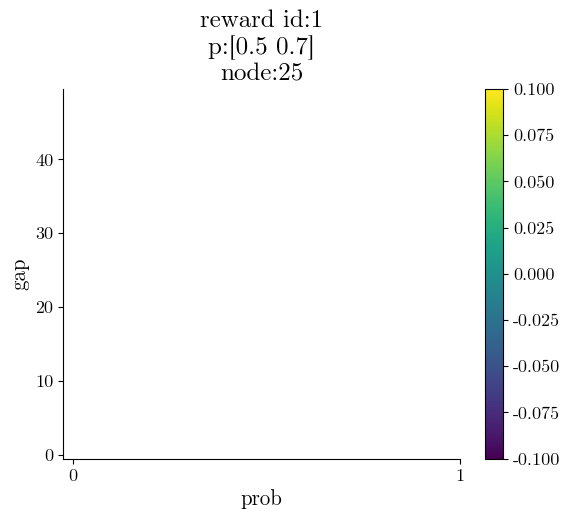

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:88: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:90: RuntimeWarning: divide by zero encountered in log
  grid=np.log(grid)
webf NOT subset; don't know how to subset; dropped


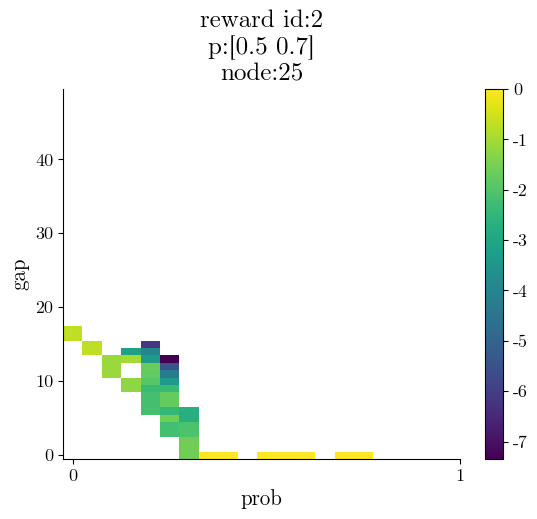

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:88: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:90: RuntimeWarning: divide by zero encountered in log
  grid=np.log(grid)
webf NOT subset; don't know how to subset; dropped


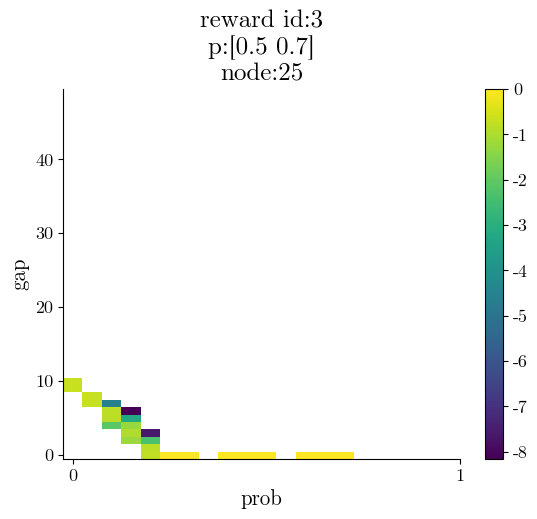

/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:88: RuntimeWarning: invalid value encountered in divide
  col = col/np.sum(col)
/var/folders/93/7tm1cj7d04l46ys7ndh7qnz80000gn/T/ipykernel_48879/392086710.py:90: RuntimeWarning: divide by zero encountered in log
  grid=np.log(grid)
webf NOT subset; don't know how to subset; dropped


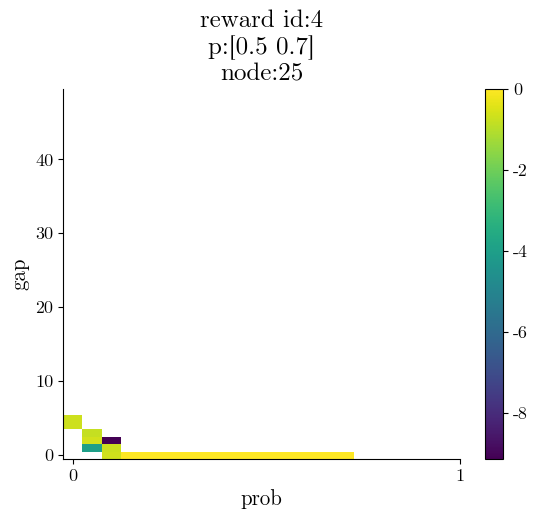

In [122]:
# eval collection -------------------
no_episodes=3333
results = []
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=8) as pool:
    # for p. vary r.
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

for episode in all_episode_data:
    episode['at_times'] = np.where(
        np.array([elt[1] for elt in episode['actions']]) == 1)[0].astype('int')
    episode['at_seq'] = [float(elt[1])
                            for elt in episode['actions']]
    if episode['actions'][-1][0] == 1:
        episode['licktime'] = int(len(episode['states']))
    else:
        episode['lick_licktimetime'] = -1
    episode['trial_len'] = len(episode['actions'])

    results.append(episode)

df = pd.DataFrame(results)



vmin, vmax = 0, 50
nbin = 20
bins = np.linspace(0, 1, nbin)

for food_reward_idx in range(len(food_reward_list)):
    fig = plt.figure()
    grid = np.zeros((vmax, nbin))
    bindata = [[] for _ in range(nbin)]
    subdf = df[(df.trial_food_reward_idx == food_reward_idx)]
    sb, nextatt = [], []
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a, b = trialnextatt(alist, b), trialsb(b)
            for j in range(len(b)):
                thisa, thisb = a[j], b[j]
                for i, (s, e) in enumerate(zip(bins, bins[1:])):
                    if s < thisb <= e:
                        bindata[i].append(thisa)
        except:
            continue
    for i in range(nbin):
        count = Counter(bindata[i])
        col = []
        for j in range(vmin, vmax):
            col.append(count[j])
        col = np.array(col)
        col = col/np.sum(col)
        grid[:, i] = col
    c = plt.imshow(grid, aspect='auto', origin='lower')
    plt.colorbar(c)
    plt.xlabel('prob')
    plt.ylabel('gap')
    plt.xticks([0,nbin],[0,1])
    plt.title(f'reward id:{food_reward_idx}\np:{p1p2}\nnode:{25}')
    quicksave(f'vary reward {food_reward_idx}, peroid', 'test', fig=fig)
    plt.show()
for food_reward_idx in range(len(food_reward_list)):
    fig = plt.figure()
    grid = np.zeros((vmax, nbin))
    bindata = [[] for _ in range(nbin)]
    subdf = df[(df.trial_food_reward_idx == food_reward_idx)]
    sb, nextatt = [], []
    for alist, b in zip(subdf.at_times, subdf.beliefs):
        try:
            a, b = trialnextatt(alist, b), trialsb(b)
            for j in range(len(b)):
                thisa, thisb = a[j], b[j]
                for i, (s, e) in enumerate(zip(bins, bins[1:])):
                    if s < thisb <= e:
                        bindata[i].append(thisa)
        except:
            continue
    for i in range(nbin):
        count = Counter(bindata[i])
        col = []
        for j in range(vmin, vmax):
            col.append(count[j])
        col = np.array(col)
        col = col/np.sum(col)
        grid[:, i] = col
    grid=np.log(grid)
    c = plt.imshow(grid, aspect='auto', origin='lower')
    plt.colorbar(c)
    plt.xlabel('prob')
    plt.ylabel('gap')
    plt.xticks([0,nbin],[0,1])
    plt.title(f'reward id:{food_reward_idx}\np:{p1p2}\nnode:{25}')
    quicksave(f'vary reward {food_reward_idx}, peroid, log', 'test', fig=fig)
    plt.show()

In [123]:
# autocorr
from ult import empirical_autocorrelation_new
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

use_reward = [2, 3, 4]
# auto correlation
for i, food_reward_idx in enumerate(use_reward):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation_new(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
             label=f'food reward={food_reward_list[food_reward_idx]:.0f}', color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2, color=rewardcmap(np.linspace(0, 1, len(use_reward)))[i])

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50, 50)
    # ax1.set_ylim(None, 1)
    ax1.set_xticks([-50, 0, 50])
    # ax1.set_yscale('log')
    ax1.set_yticks([1])
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.tick_params(axis='x', pad=50) 

    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_xticks([0, 40, 80])
    ax2.set_yticks([])
    ax2.set_title('trial length distribution')

color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap=rewardcmap), ax=ax2)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

fig.suptitle('varying reward, peroid')
quicksave('autocorr', 'plot p')
plt.tight_layout()


,trial_food_reward_idx,num_steps,actions,rewards,states,observations,beliefs,p1p2,q_states,q_probs,at_times,at_seq,licktime,trial_len,lick_licktimetime
0,3,24,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [0], [0], [0], [0], [1], [0], [0], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[12, 19, 20, 21, 22, 23]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",25.0,24,NaN
1,1,84,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [0], [0], [1], [0], [0], [1], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,84,-1.0
2,3,22,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [0], [1], [0], [1], [0], [0], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[12, 19, 20, 21]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",23.0,22,NaN
3,1,130,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [1], [0], [0], [1], [1], [0], [0], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,130,-1.0
4,2,22,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [0], [0], [0], [1], [1], [1], [0], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[19, 20, 21]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",23.0,22,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,3,57,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [1], [0], [0], [0], [1], [0], [0], [0], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[12, 19, 26, 33, 40, 47, 54, 55, 56]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",58.0,57,NaN
3329,4,15,"[[1, 1], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[-1.6, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.6, 0.0...","[[27], [0], [0], [0], [0], [0], [1], [2], [3],...","[[3], [0], [0], [0], [1], [0], [1], [0], [0], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0, 7, 11, 12, 13, 14]","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",16.0,15,NaN
3330,1,60,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[27], [0], [0], [0], [0], [0], [0], [0], [0],...","[[3], [0], [1], [1], [0], [1], [1], [1], [1], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.5, 0.7]","[[0], [1], [2], [3], [4], [5], [6], [7], [8], ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,60,-1.0
3331,1,61,"[[1, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0,